# SpaceX S-1 — Connectivity (Starlink) segment economics

An open analysis of the Connectivity (Starlink) segment from SpaceX's Form S-1, for readers who know
technology but not necessarily finance. Finance terms are defined inline; the engineering is assumed.

**The one question this notebook answers: how much cash does Starlink actually generate?** Not accounting
profit, not EBITDA — cash, after paying to replace the hardware that physically wears out. For a business
whose assets literally burn up, that distinction is the whole story.

**Data.** Every input is a GAAP figure from the S-1 segment disclosures, loaded from `csv/` via
`analysis.data`. The full filing text is in `source_docs/spacex-s1.pdf`. The only input that is *not*
from the S-1 is SpaceX's internal marginal cost to fly one reused Falcon 9 (~\$15–20M), which the
company does not disclose.

**Method — why free cash flow is the measure that matters.**
- **Free cash flow (FCF) = cash from operations (CFO) − capex.** This is the cash left over *after* the
  business pays to build and replace its assets. It is what an owner can actually take out, and it is what
  a valuation discounts. The S-1 reports CFO only on a consolidated basis, so at the segment level we build
  a CFO proxy from fundamentals: operating income plus the non-cash charges (depreciation & amortization,
  stock-based compensation, impairment). It excludes working-capital movements, which for Starlink are a
  cash *source* (subscriptions are prepaid) — so the proxy is deliberately conservative.
- **EBITDA is shown for comparison only — never used in a calculation.** EBITDA = earnings before interest,
  taxes, depreciation, and amortization. Adding depreciation back assumes it is a paper charge that doesn't
  cost real money. For most asset-light software, that is roughly fair. For SpaceX it is not: the
  depreciation it strips out is the cost of hardware that is being consumed in front of us — Falcon boosters
  reach an end-of-life flight count and are retired, and Starlink satellites deorbit and burn up after a few
  years. That hardware has to be rebuilt with cash, year after year, just to stand still. FCF captures that
  replacement cost (through capex); EBITDA pretends it away. So EBITDA overstates what Starlink earns, and we
  use it only to show *how large* that overstatement is.
- Dollar figures are in millions USD. Periods: FY2023–FY2025 (years to Dec 31) and Q1-2026 (three
  months to Mar 31, 2026).

In [1]:
# Locate the repo root (the directory containing `analysis/`) so imports work from anywhere.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "analysis")):
    _p = os.path.dirname(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import data, charts
from analysis.connectivity_economics import (
    ConnectivityModel, PERIODS, INTERNAL_LAUNCH_COST_M, KIT_SHARE, SAT_LIFE_SENSITIVITY_M)

charts.apply_style()
TEAL, NAVY, ORANGE = charts.SEGMENT_COLORS["Connectivity"], charts.SEGMENT_COLORS["Space"], charts.SEGMENT_COLORS["AI"]

R = ConnectivityModel().raw()      # per-period Connectivity fundamentals from the S-1 CSVs

def fmt(df, pct=(), one=()):
    """Table display helper: percent for margin cols, 1 decimal for per-launch cols, else $M integers."""
    spec = {c: ("{:.1%}" if c in pct else ("{:,.1f}" if c in one else "{:,.0f}")) for c in df.columns}
    return df.style.format(spec)

R.T   # the raw S-1 inputs every later calculation is built from

period,FY2023,FY2024,FY2025,Q1-2026
revenue,3869.000,7599.000,11387.00,3257.000
op_income,469.000,2006.000,4423.00,1188.000
cogs,2786.000,4768.000,5921.00,1651.000
rnd,381.000,453.000,575.00,205.000
sga,233.000,333.000,468.00,213.000
restructuring,0.000,0.000,0.00,0.000
impairment,0.000,39.000,0.00,0.000
da,884.000,1508.000,2376.00,783.000
sbc,249.000,296.000,369.00,116.000
capex,2455.000,3498.000,4178.00,1332.000


## 1. Launch costs are inside the Connectivity segment

A natural question: are Starlink's launch costs buried in the Space segment, which would make
Connectivity look more profitable than it is? The S-1 answers it directly — they are **capitalized
into Connectivity and depreciated**:

> **MD&A (p. 81):** "For launches dedicated to deploying our Starlink satellites, *we capitalize the
> associated costs within our Connectivity segment and depreciate them over time*, and we do not
> recognize revenue for those launches in our Space segment."

> **PP&E note (F-14):** "Satellites include costs to build the satellites … as well as *capitalized
> launch costs incurred by the Space segment to launch the satellites to orbit, which include an
> allocation of the flight vehicle hardware costs*."

The FY2025 cost-of-revenue change is even attributed to *"higher depreciation of \$827M from
capitalized launch and satellite costs."* So reported operating income **already includes launch
cost** — as depreciation of capitalized launch spend, at SpaceX's internal cost. The same spend also
sits in capex, so the FCF below captures it too.

In [2]:
pl = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
pl["Revenue"]          = R.revenue
pl["Operating income"] = R.op_income
pl["Op margin"]        = R.op_income / R.revenue
pl["D&A"]              = R.da
pl["Capex"]            = R.capex
fmt(pl, pct=["Op margin"])

,Revenue,Operating income,Op margin,D&A,Capex
period,,,,,
FY2023,"3,869",469,12.1%,884,"2,455"
FY2024,"7,599","2,006",26.4%,"1,508","3,498"
FY2025,"11,387","4,423",38.8%,"2,376","4,178"
Q1-2026,"3,257","1,188",36.5%,783,"1,332"


## 2. Where the cost of revenue goes ($5,921M, FY2025)

The S-1 lists the cost-of-revenue components (p. 100) — *"depreciation (inclusive of launch, satellite,
and ground infrastructure costs), Starlink Kit costs, shipping and handling, ground operating expenses,
employee compensation … payment processor fees, warranty … customs and duties"* — but not their dollar
amounts. We anchor the one disclosed (depreciation = segment D&A) and treat the rest as a residual
"cash COGS". The split of that residual into hardware vs. network is **illustrative** (not disclosed);
Starlink Kits are sold near cost, so they are roughly pass-through.

,FY2025 ($M)
Cost of revenue,5921.0
Depreciation (launch+sat+ground),2376.0
Cash COGS (everything else),3545.0
~ Starlink Kit hardware (est.),1418.0
~ Network ops/support/fees (est.),2127.0


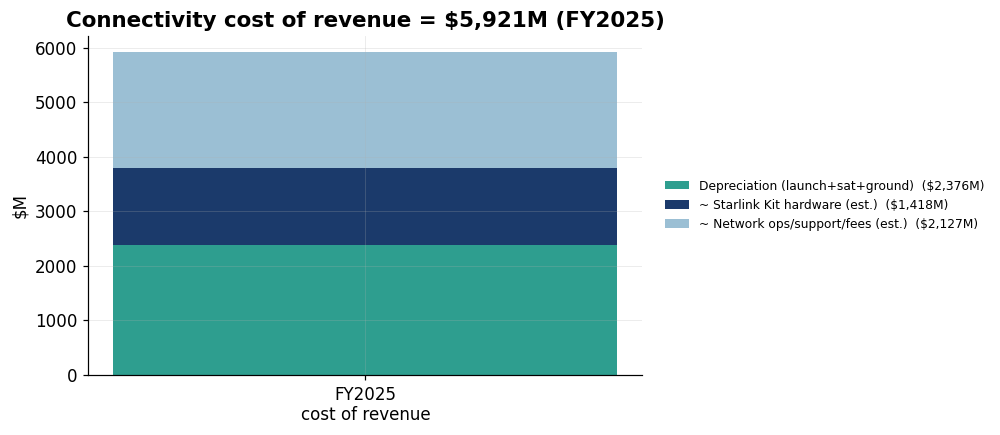

In [3]:
cogs25, da25 = R.cogs["FY2025"], R.da["FY2025"]
cash_cogs = cogs25 - da25
kit       = cash_cogs * KIT_SHARE

cd = pd.Series({
    "Cost of revenue":                    cogs25,
    "Depreciation (launch+sat+ground)":   da25,
    "Cash COGS (everything else)":        cash_cogs,
    "~ Starlink Kit hardware (est.)":     kit,
    "~ Network ops/support/fees (est.)":  cash_cogs - kit,
}, name="FY2025 ($M)")
display(cd.round(0).to_frame())

parts = cd[["Depreciation (launch+sat+ground)", "~ Starlink Kit hardware (est.)", "~ Network ops/support/fees (est.)"]]
fig, ax = plt.subplots(figsize=(6.5, 4)); bottom = 0
for (label, val), c in zip(parts.items(), [TEAL, NAVY, "#9bbfd4"]):
    ax.bar("FY2025\ncost of revenue", val, bottom=bottom, color=c, label=f"{label}  (${val:,.0f}M)")
    bottom += val
ax.set_title("Connectivity cost of revenue = $5,921M (FY2025)")
ax.set_ylabel("$M"); ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
charts.save(fig, "connectivity_cogs"); plt.show()

About **40% of cost of revenue is depreciation of the constellation** (launch + satellite + ground), and
it is the fastest-growing component (+\$827M year over year). This is the single most important fact about
Starlink's cost structure: the dominant cost is not bandwidth, support, or hardware shipped to customers —
it is the **steady write-down of a satellite fleet that is physically being used up.** Starlink satellites
operate for only a few years before atmospheric drag pulls them down to burn up on reentry, so the fleet
must be continuously rebuilt and relaunched just to keep service running. Depreciation is the accounting
shadow of that physical reality, and the S-1 quantifies how sharp it is: a ±1-year change in assumed
satellite useful life moves FY2025 operating income by about **\$480M**. Because this cost is large, real,
and recurring, any measure that adds it back — EBITDA — describes a business that does not exist. That is
the subject of the next section.

## 3. Cash flow, not EBITDA

This is the heart of the analysis. To value Starlink we need the cash it actually throws off after keeping
its constellation alive — not a profit figure that ignores the cost of replacing satellites that fall out
of the sky.

**FCF = CFO − capex.** We build the segment CFO proxy from fundamentals (operating income + the non-cash
charges), then subtract capex — the cash spent building and replacing satellites, ground stations, and
launch hardware. What survives that subtraction is real free cash flow.

In [4]:
ff = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
ff["Operating income"]              = R.op_income
ff["+ D&A (non-cash)"]              = R.da
ff["+ SBC (non-cash)"]             = R.sbc
ff["+ Impairment (non-cash)"]      = R.impairment
ff["= CFO (proxy, excl. ΔWC)"]     = R.op_income + R.da + R.sbc + R.impairment
ff["− Capex"]                      = -R.capex
ff["= FCF"]                        = (R.op_income + R.da + R.sbc + R.impairment) - R.capex
ff["FCF margin"]                   = ff["= FCF"] / R.revenue
ff["Maintenance capex (≈ D&A)"]    = R.da
ff["Growth capex (capex − D&A)"]   = R.capex - R.da
fmt(ff, pct=["FCF margin"])

,Operating income,+ D&A (non-cash),+ SBC (non-cash),+ Impairment (non-cash),"= CFO (proxy, excl. ΔWC)",− Capex,= FCF,FCF margin,Maintenance capex (≈ D&A),Growth capex (capex − D&A)
period,,,,,,,,,,
FY2023,469,884,249,0,"1,602","-2,455",-853,-22.0%,884,"1,571"
FY2024,"2,006","1,508",296,39,"3,849","-3,498",351,4.6%,"1,508","1,990"
FY2025,"4,423","2,376",369,0,"7,168","-4,178","2,990",26.3%,"2,376","1,802"
Q1-2026,"1,188",783,116,0,"2,087","-1,332",755,23.2%,783,549


These segment building blocks tie out to the consolidated cash-flow statement — a check that the
proxy is on the right basis (the three segments' D&A, SBC, and capex each sum to the consolidated
FY2025 lines):

In [5]:
sup, cf = data.load("segment_supplemental"), data.load("cash_flow")
checks = [("Depreciation and amortization", "Depreciation and amortization"),
          ("Share-based compensation",      "Share-based compensation"),
          ("Capital expenditures",          "Purchases of property plant and equipment")]
rows = {}
for seg_metric, cf_item in checks:
    seg_sum = sup[(sup.metric == seg_metric) & (sup.period == "FY2025")]["value"].sum()
    cons    = abs(cf[(cf.line_item == cf_item) & (cf.period == "FY2025")]["value"].iloc[0])
    rows[seg_metric] = {"segments summed": seg_sum, "consolidated cash flow": cons, "match": seg_sum == cons}
pd.DataFrame(rows).T

,segments summed,consolidated cash flow,match
Depreciation and amortization,6701,6701,True
Share-based compensation,1947,1947,True
Capital expenditures,20737,20737,True


### Why EBITDA is misleading here (shown for comparison only)
EBITDA adds depreciation back to profit, on the theory that depreciation is a bookkeeping entry rather than
a cash cost. **For SpaceX that theory is false.** The depreciation being added back is the using-up of real
hardware: Falcon boosters hit an end-of-life flight count and are retired, and Starlink satellites deorbit
and burn up after a few years. None of it can be reused — it must be physically rebuilt and reflown, with
cash, every year. That replacement spending is exactly what shows up in capex, which EBITDA conveniently
leaves out. So EBITDA describes a fictional Starlink that never has to replace anything. FCF — profit plus
non-cash charges, *minus* the capex that funds replacement — describes the real one. The table and chart
below show how far apart the two are.

In [6]:
cmp = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
cmp["GAAP EBITDA (op income + D&A)"]            = R.op_income + R.da
cmp["Adj. EBITDA (S-1: +SBC +restr +impair)"]   = R.adj_ebitda_reported   # comparison only
cmp["FCF (CFO − capex)"]                         = (R.op_income + R.da + R.sbc + R.impairment) - R.capex
cmp["EBITDA − FCF (asset-replacement cash)"]    = (R.op_income + R.da) - cmp["FCF (CFO − capex)"]
fmt(cmp)

,GAAP EBITDA (op income + D&A),Adj. EBITDA (S-1: +SBC +restr +impair),FCF (CFO − capex),EBITDA − FCF (asset-replacement cash)
period,,,,
FY2023,"1,353","1,602",-853,"2,206"
FY2024,"3,514","3,849",351,"3,163"
FY2025,"6,799","7,168","2,990","3,809"
Q1-2026,"1,971","2,087",755,"1,216"


### Charting a full year: the FY2026E estimate

We have only one quarter of fiscal 2026 (Q1, to Mar 31). Dropping that three-month stub next to full
years would make every chart look like the business fell off a cliff, so for the time-series charts we
replace it with a full-year estimate, **FY2026E**, built straight from the quarter in hand: grow each
FY2025 line item by its own **Q1-2026-over-Q1-2025 growth rate**. This is a mechanical run-rate
extrapolation — *if the year-over-year pace set in Q1 holds, where does the full year land?* — not a
bottom-up forecast. FY2026E is drawn **hatched** in every chart to flag it as an estimate; the tables
above keep the actual reported quarter.

The estimate carries a signal worth reading before the chart: revenue grows ~32% and EBITDA keeps
climbing, but **capex is accelerating faster (+64% YoY) than operating income (+15%)**, so projected FCF
holds roughly flat instead of rising. That is reinvestment, not deterioration — SpaceX is plowing the
quarter's extra cash straight back into expanding the fleet.

In [7]:
# FY2026E — annualize the partial Q1-2026 quarter so the charts compare like with like.
# Method: grow each FY2025 line item by its own Q1-2026 / Q1-2025 (year-over-year) rate.
Q     = ConnectivityModel().raw(["Q1-2025", "Q1-2026"])   # both first quarters, same columns as R
yoy   = Q.loc["Q1-2026"] / Q.loc["Q1-2025"]               # per-line year-over-year growth
fy26e = R.loc["FY2025"] * yoy
fy26e["impairment"] = 0.0; fy26e["restructuring"] = 0.0   # none assumed in the estimate

CHART_PERIODS = ["FY2023", "FY2024", "FY2025", "FY2026E"]
def to_chart(series, est):
    """Three reported full years (from an R column) + the FY2026E estimate."""
    return list(series.loc[["FY2023", "FY2024", "FY2025"]]) + [est]

keys = ["revenue", "op_income", "da", "sbc", "capex"]
est  = pd.DataFrame({"FY2025 (actual)": R.loc["FY2025", keys],
                     "Q1 YoY growth":   yoy[keys] - 1,
                     "FY2026E (est.)":  fy26e[keys]})
fmt(est, pct=["Q1 YoY growth"])

,FY2025 (actual),Q1 YoY growth,FY2026E (est.)
revenue,"11,387",31.6%,"14,985"
op_income,"4,423",15.0%,"5,087"
da,"2,376",53.5%,"3,648"
sbc,369,54.7%,571
capex,"4,178",63.6%,"6,837"


In [ ]:
from matplotlib.patches import Patch
fig, ax = plt.subplots()
ebitda = to_chart(R.op_income + R.da,
                  fy26e["op_income"] + fy26e["da"])
fcf    = to_chart((R.op_income + R.da + R.sbc + R.impairment) - R.capex,
                  fy26e["op_income"] + fy26e["da"] + fy26e["sbc"] + fy26e["impairment"] - fy26e["capex"])
opinc  = to_chart(R.op_income, fy26e["op_income"])
x = np.arange(len(CHART_PERIODS))

b_eb = ax.bar(x, ebitda, width=0.5, color="#cfe5e1", label="GAAP EBITDA (ignores asset replacement)")
b_fc = ax.bar(x, fcf,    width=0.5, color=TEAL,      label="FCF = CFO − capex")
ax.plot(x, opinc, "o--", color=NAVY, label="Operating income")
for bars, hatch_c in ((b_eb, "#7fb0a8"), (b_fc, "white")):   # hatch the FY2026E (last) bar = estimate
    bars[-1].set_hatch("//"); bars[-1].set_edgecolor(hatch_c); bars[-1].set_linewidth(0)
ax.axhline(0, color="#444", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_title("Starlink: EBITDA overstates cash; FCF stays positive through the capex ramp ($M)")
ax.set_ylabel("$M")
handles, _ = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)"))
ax.legend(handles=handles)
charts.save(fig, "connectivity_fcf"); plt.show()

In FY2025 GAAP EBITDA was ~\$6.8B, but **real free cash flow was ~\$3.0B** — EBITDA overstates cash
generation by roughly **2×**. The ~\$3.8B gap is not an accounting artifact; it is the cash SpaceX spent
replacing and growing hardware that the EBITDA figure simply ignores. Anyone valuing Starlink off EBITDA is
valuing a company that gets to keep its satellites for free.

The honest figure, FCF, traces a clean infrastructure **J-curve**: −\$0.9B (2023) → +\$0.4B (2024) →
+\$3.0B (2025). Early years are cash-negative because the fleet is being built ahead of the revenue; once
the base is in place, each incremental subscriber drops far more cash to the bottom line. On the Q1-2026
run-rate (the hatched **FY2026E** bar), FCF holds near ~\$2.5B even as revenue grows ~32% — capex is
ramping faster than profit, so the gains are being reinvested into fleet expansion rather than released as
free cash flow. That is a choice, not a ceiling: it is the next point that determines value.

**Maintenance vs. growth capex.** Not all of that capex is replacement. Holding the constellation steady —
replacing satellites as they deorbit — costs roughly the depreciation amount, ≈\$2,376M in FY2025; the
remaining ~\$1.8B is *growth* capex, expanding the fleet and coverage. This split is what makes the
business look better over time: as subscriber growth matures and growth capex tapers toward bare
maintenance, FCF rises toward the high-30s% of revenue (its operating-margin territory). Two honest
caveats: stock-based compensation is added back as non-cash but is a real dilution cost (~\$369M in
FY2025), and the proxy excludes prepaid-subscription working capital, which would *raise* CFO — i.e., the
real number is, if anything, a little better than shown.

## 4. The launch-cost moat: an internal vs. market price gap

Connectivity is charged for launch at SpaceX's **internal marginal cost** (~\$15–20M per reused
Falcon 9). An independent operator would pay the **customer price**, derived from the S-1's own
customer launch economics:

$$\text{market price per launch} = \frac{\text{Space revenue} \times \text{Launch-Services share}}{\text{customer launches}}$$

Internal Starlink launch counts are S-1 actuals (footnote, p. 87): 63 → 89 → 122 over 2023–2025. The
quarterly market price is noisy (small customer-launch denominator); the full-year figures (~\$58–60M)
are the reliable reference. The chart's **FY2026E** bar applies that ~\$60M reference to the projected
~168 Starlink launches (FY2025 launches grown at the Q1 year-over-year rate).

In [9]:
market_price = R.space_revenue * R.ls_pct / R.customer_launches   # S-1-implied $/launch
spread       = market_price - INTERNAL_LAUNCH_COST_M

le = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
le["Starlink launches"]              = R.starlink_launches
le["Customer launches"]              = R.customer_launches
le["Market $/launch (S-1)"]          = market_price
le["Internal $/launch"]              = INTERNAL_LAUNCH_COST_M
le["Spread $/launch"]                = spread
le["Internal launch cash"]           = R.starlink_launches * INTERNAL_LAUNCH_COST_M
le["At market price"]                = R.starlink_launches * market_price
le["Vertical-integration advantage"] = le["At market price"] - le["Internal launch cash"]
le["Standalone op income"]           = R.op_income - spread * R.starlink_launches  # if launch bought at market
le["Standalone op margin"]           = le["Standalone op income"] / R.revenue
fmt(le, pct=["Standalone op margin"], one=["Market $/launch (S-1)", "Internal $/launch", "Spread $/launch"])

,Starlink launches,Customer launches,Market $/launch (S-1),Internal $/launch,Spread $/launch,Internal launch cash,At market price,Vertical-integration advantage,Standalone op income,Standalone op margin
period,,,,,,,,,,
FY2023,63,33,59.5,17.5,42.0,"1,102","3,748","2,646","-2,177",-56.3%
FY2024,89,45,57.5,17.5,40.0,"1,558","5,120","3,563","-1,557",-20.5%
FY2025,122,43,59.9,17.5,42.4,"2,135","7,303","5,168",-745,-6.5%
Q1-2026,33,7,47.1,17.5,29.6,578,"1,555",978,210,6.5%


In [ ]:
from matplotlib.patches import Patch
mp = R.space_revenue * R.ls_pct / R.customer_launches        # full-year market $/launch (S-1-implied)
sl = to_chart(R.starlink_launches, fy26e["starlink_launches"])
internal_cash = [s * INTERNAL_LAUNCH_COST_M for s in sl]
# FY2026E market price holds FY2025's reliable full-year ~$60M (quarterly price is too noisy to project)
at_market = to_chart(R.starlink_launches * mp, fy26e["starlink_launches"] * mp["FY2025"])
adv = [m - i for m, i in zip(at_market, internal_cash)]

x = np.arange(len(CHART_PERIODS)); w = 0.38
fig, ax = plt.subplots()
b_i = ax.bar(x - w/2, internal_cash, w, color=TEAL,   label="At internal cost (~$17.5M/launch)")
b_m = ax.bar(x + w/2, at_market,     w, color=ORANGE, label="At customer price (~$60M/launch)")
for bars in (b_i, b_m):                                       # hatch the FY2026E (last) bar = estimate
    bars[-1].set_hatch("//"); bars[-1].set_edgecolor("white"); bars[-1].set_linewidth(0)
for i in range(len(CHART_PERIODS)):
    ax.text(i, at_market[i] + 150, f"+${adv[i]:,.0f}M", ha="center", fontsize=8, color="#444")
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_ylim(top=max(at_market) * 1.12)
ax.set_title("Cost of Starlink's launches: internal cost vs. market price ($M)")
ax.set_ylabel("$M")
handles, _ = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)"))
ax.legend(handles=handles)
charts.save(fig, "connectivity_launch_moat"); plt.show()

In FY2025 self-launching saved roughly **\$5.2B** versus buying launch at market (Falcon 9 reuse:
157 of 165 FY2025 flights used flight-proven boosters). Re-pricing launch at the ~\$60M customer price
turns the segment's operating profit into a small **loss** at FY2025 revenue — it only stays positive
if launch costs less than ~\$23–25M. The reported ~39% operating margin is real but depends on owning
the rockets.

In [11]:
mp25, op25, sl25, rev25 = (market_price["FY2025"], R.op_income["FY2025"],
                            R.starlink_launches["FY2025"], R.revenue["FY2025"])
sens = pd.DataFrame({"Internal $/launch": [15, 17.5, 20, 25]})
sens["Spread $/launch"]      = mp25 - sens["Internal $/launch"]
sens["Standalone op income"] = op25 - sens["Spread $/launch"] * sl25
sens["Standalone op margin"] = sens["Standalone op income"] / rev25
fmt(sens.set_index("Internal $/launch"), pct=["Standalone op margin"], one=["Spread $/launch"])

,Spread $/launch,Standalone op income,Standalone op margin
Internal $/launch,,,
15.000000,44.9,"-1,050",-9.2%
17.500000,42.4,-745,-6.5%
20.000000,39.9,-440,-3.9%
25.000000,34.9,170,1.5%


## 5. Opportunity cost of a Starlink-dedicated rocket

If every FY2025 Starlink launch could instead have been sold to a customer, the forgone amount would be
large (the ceiling below). But that assumes unlimited external demand. SpaceX flew only **43 customer
launches** versus **122** for Starlink, and the S-1 states that Starlink *backfills* otherwise-idle
launch slots:

> *"When an expected customer payload for a planned launch is not available, we instead use launch
> capacity for our satellites."*

External demand — not launch capacity — is the binding constraint, so the **realistic marginal
opportunity cost is close to zero**: Starlink monetizes capacity that would otherwise go unused. (If
future external or internal launch demand exceeds capacity, this opportunity cost would rise.)

In [12]:
oc = pd.Series({
    "Starlink launches":               sl25,
    "Customer launches":               R.customer_launches["FY2025"],
    "Ceiling: forgone revenue":        sl25 * mp25,
    "Ceiling: forgone margin":         sl25 * (mp25 - INTERNAL_LAUNCH_COST_M),
    "Realistic marginal (backfill)":   0.0,
}, name="FY2025 ($M)")
oc.round(0).to_frame()

,FY2025 ($M)
Starlink launches,122.0
Customer launches,43.0
Ceiling: forgone revenue,7303.0
Ceiling: forgone margin,5168.0
Realistic marginal (backfill),0.0


## Open threads
- **Subscriber / ARPU model:** project the point at which growth capex tapers and FCF margin converges
  toward the operating margin; decompose ARPU decline (\$99→\$81/yr) into mix shift vs. price.
- **Working capital:** size the prepaid-subscription / deferred-revenue cash benefit for Connectivity
  to refine the CFO proxy (consolidated deferred-revenue inflow was ~\$1.9B in FY2025).
- **Satellite unit economics:** infer \$/satellite and implied satellite count from the Satellites PP&E
  line (\$11,949M gross) and the ~\$480M/yr life sensitivity.
- **Forward opportunity cost:** rises above zero if launch demand outgrows capacity.